In [56]:
import tensorflow.keras as tf 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [57]:
df = pd.read_csv("./Churn.csv")

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [59]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
clean_df = df.drop(columns=["customer_id"])
clean_df = clean_df.dropna()
clean_df = clean_df.drop_duplicates()

In [61]:
X = clean_df.drop(columns="churn")
y = clean_df["churn"]

In [62]:
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=99)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.5, random_state=58)

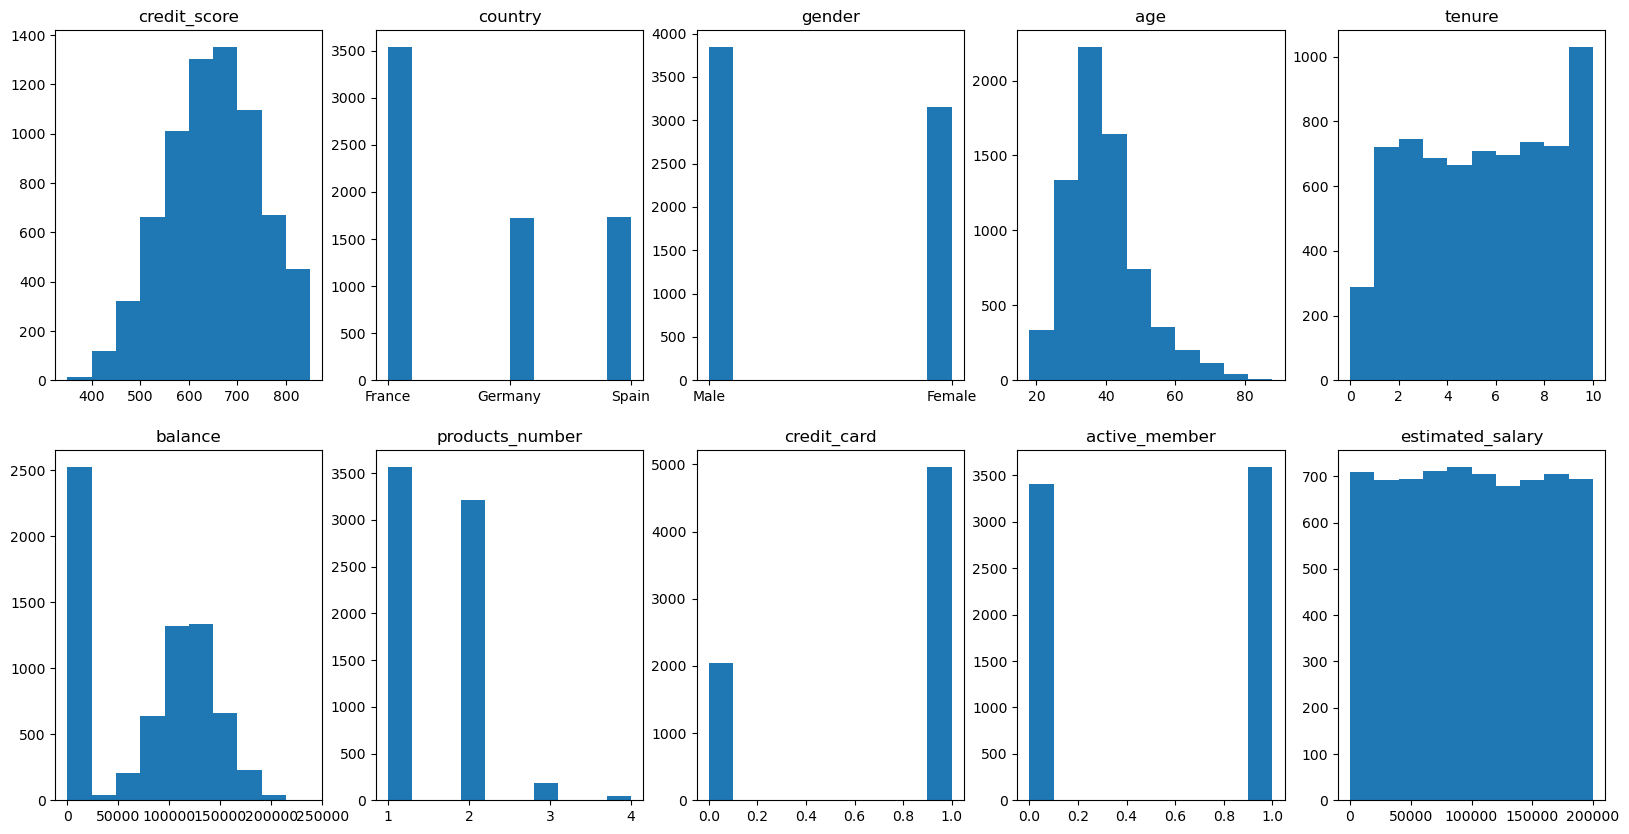

In [63]:
plt.figure(figsize=(20,10))

for i, col in enumerate(x_train.columns):
    plt.subplot(2, 5, i+1)
    plt.hist(x_train[col]) 
    plt.title(col)
plt.show()

In [64]:
# Encode
# Label/Ordinal: data label yang hierarkis
# One Hot: data yang setara

In [65]:
categorical_col = ['country', 'gender']
numerical_cols = ['credit_score', 'age', 'tenure', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

In [66]:
preprocess = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_col),
        ('scaler', StandardScaler(), numerical_cols)
    ]
)

In [ ]:
x_train = preprocess.fit_transform(x_train)
x_test = preprocess.transform(x_test)
x_val = preprocess.transform(x_val)

In [69]:
model = tf.models.Sequential([
    tf.layers.Dense(64, activation="relu", input_shape=(x_train.shape[1],)),
    tf.layers.Dense(32, activation="relu"),
    tf.layers.Dense(16, activation="relu"),
    tf.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history = model.fit(
    x_train, 
    y_train, 
    epochs=100, 
    validation_data=(x_val, y_val)
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.7025 - loss: 0.5532 - val_accuracy: 0.8327 - val_loss: 0.4135
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8521 - loss: 0.3757 - val_accuracy: 0.8433 - val_loss: 0.3818
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - accuracy: 0.8584 - loss: 0.3529 - val_accuracy: 0.8407 - val_loss: 0.3728
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.8518 - loss: 0.3551 - val_accuracy: 0.8533 - val_loss: 0.3736
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.8630 - loss: 0.3372 - val_accuracy: 0.8413 - val_loss: 0.3651
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8546 - loss: 0.3479 - val_accuracy: 0.8433 - val_loss: 0.3675
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.8633 - loss: 0.3371 - val_accuracy: 0.8480 - val_loss: 0.3635
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.8629 - loss: 0

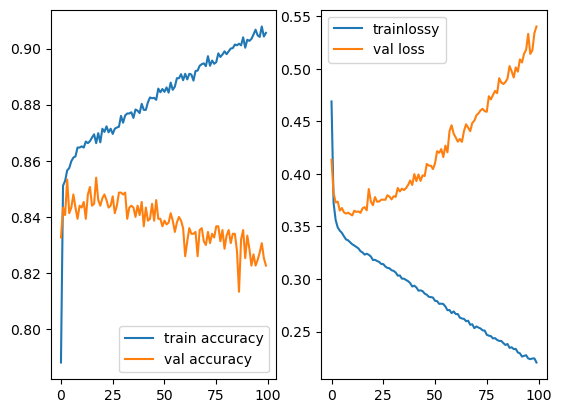

In [74]:
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history['val_accuracy'], label="val accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="trainlossy")
plt.plot(history.history['val_loss'], label="val loss")
plt.legend()

plt.show()

In [75]:
model.evaluate(x_test, y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 0.8453 - loss: 0.4826


[0.4778446555137634, 0.8500000238418579]